In [1]:
"""
Letter decoding with mean‐template classifiers + cross‐session alignment.

Pipeline:
1) Load and precompute shared metadata (letters, sessions, windows).
2) For each bootstrap/permutation:
   a) Build session dictionaries expected by `compute_session_alignment`.
   b) Align sessions into a common subspace.
   c) Project trials and run mean‐template decoding in sliding time windows.
3) Aggregate across permutations and save per‐letter time×time decoding maps.
4) Perform cluster‐based permutation tests and plot significance overlays.

NOTE: This file adds comments and light structure only; algorithmic behavior
remains the same. Look for "TODO" tags on potential issues.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pickle
import glob
import sys

# Make local code importable (expects Code/compute_session_alignment.py)
sys.path.append('./Code/')
import compute_session_alignment

from collections import Counter
from joblib import Parallel, delayed

# ---------------------------------------------------------------------
# Decoders: mean‐template variants
# ---------------------------------------------------------------------
def letter_decoding_mean(x_train, x_test, y_train, y_test, shuffle=False):
    """
    Mean‐template decoding that compares per‐class mean TEST activity to
    per‐class mean TRAIN templates using cosine similarity, but counts
    accuracy at the **class‐mean** level (i.e., 1 correct per class).

    Args
    ----
    x_train, x_test : array (trials × time × features) BEFORE windowing.
    y_train, y_test : array (trials,) with discrete class labels.
    shuffle         : bool, if True shuffles y labels for a null/control.

    Returns
    -------
    score_matrix : (n_win × n_win) array of counts (not normalized).
                   Entry (ti, tj) = number of classes correctly predicted
                   when training a template at window ti and testing on
                   class means at window tj.
    n_classes    : int, number of unique classes present in training labels.
    """
    
    n_win = len(window_ranges)
    score_matrix = np.zeros((n_win, n_win))

    # Copy/alias labels (already integers/strings)
    y_train_encoded = y_train
    y_test_encoded  = y_test
    class_labels    = [0,1] #np.unique(y_train_encoded)

    # Average activity in sliding windows and baseline‐correct by FIX bins
    #print((x_train.shape,x_test.shape),flush=True)
    xTTrain_all = [np.mean(x_train[:, start:end, :], axis=1) #- np.mean(x_train[:, 0:4, :], axis=1)
                   for (start, end) in window_ranges]
    xTTest_all  = [np.mean(x_test[:, start:end, :], axis=1)  #- np.mean(x_test[:, 0:4, :], axis=1)
                   for (start, end) in window_ranges]

    if shuffle:
        # Shuffle labels independently for train/test for a conservative null
        np.random.shuffle(y_train_encoded)
        np.random.shuffle(y_test_encoded)

    all_templates = []  # keep templates from each TRAIN window (for inspection)
    for ti, xTTrain in enumerate(xTTrain_all):
        for tj, xTTest in enumerate(xTTest_all):
            if(ti==tj):
                # --- TRAIN: build one mean template per class (in window ti)
                templates = []
                for c in class_labels:
                    class_indices = np.where(y_train_encoded == c)[0]
                    template = np.mean(xTTrain[class_indices], axis=0)
                    templates.append(template)
                templates = np.array(templates)  # (n_classes × n_features)

                if tj == 0:
                    all_templates.append(templates)

                # --- TEST: compare per‐class MEAN test activity to templates
                correct = 0
                for c_idx, c in enumerate(class_labels):
                    test_indices = np.where(y_test_encoded == c)[0]
                    if len(test_indices) == 0:
                        continue

                    # mean vector for THIS class/window
                    test_vec = np.mean(xTTest[test_indices], axis=0)

                    # Cosine similarity to each template -> scalars
                    corrs = [
                        float(np.dot(test_vec, tpl) / (np.linalg.norm(test_vec) * np.linalg.norm(tpl) + 1e-8))
                        for tpl in templates
                    ]

                    # tie-break
                    if len(corrs) == 2 and np.isclose(corrs[0], corrs[1]):
                        predicted_class_idx = np.random.choice([0, 1])
                    else:
                        predicted_class_idx = int(np.argmax(corrs))

                    predicted_class = class_labels[predicted_class_idx]
                    if predicted_class == c:
                        correct += 1
                        

            score_matrix[ti, tj] = correct  # raw count (not %)
            
    return score_matrix, 2, #len(class_labels)

In [2]:
units = np.load('../Data/units.npy',allow_pickle=True)
units[6][0]

array(['uAHL1_0', 'uAHL1_4', 'uAHL1_5', 'uAHL2_0', 'uAHL3_0', 'uAHL4_1',
       'uAHL5_0', 'uAHL7_1', 'uAHL7_4', 'uAL8_17', 'uAL8_19', 'uECL3_14',
       'uPHL2_3', 'uPHR1_1', 'uPHR3_5', 'uPHR5_1', 'uPHR6_2', 'uPHR6_4',
       'uPHR6_5', 'uPHR6_6', 'uPHR6_7', 'uPHR6_8', 'uPHR6_9', 'uPHR7_16',
       'uPHR7_2', 'uPHR7_3', 'uPHR7_8'], dtype=object)

In [3]:
completeBinned = np.load('../Data/binned.npy', allow_pickle=True)
completeBinned[1].shape

(99, 16, 16)

In [4]:
letters        = np.load('../Data/letters.npy')
uniqueLetters = np.array([p for p in np.unique(letters) if p not in ['Q', 'W', 'X']])
uniqueLetters

array(['B', 'C', 'D', 'F', 'G', 'H', 'K', 'L', 'N', 'P', 'R', 'S', 'T',
       'V', 'Z'], dtype='<U1')

In [5]:
subj_ses = np.load('../Data/subjs_sep.npy',allow_pickle=True)
len(subj_ses)

35

In [6]:
from copy import deepcopy
NPC_TO_ALIGN = 5
# ---------------------------------------------------------------------
# Shared/static variables (loaded once)
# ---------------------------------------------------------------------
# NOTE: The following variables are referenced later. Make sure they are
# defined prior to calling functions that use them.

# Load all data (paths assume ../Data/ exists)
probes         = np.load('../Data/probes.npy')
subj           = np.load('../Data/subjs.npy')
subj_ses       = np.load('../Data/subjs_sep.npy', allow_pickle=True)
inout          = np.load('../Data/in.npy')
letters        = np.load('../Data/letters.npy')
letters_ses    = np.load('../Data/letters_sep.npy', allow_pickle=True)
probes_ses     = np.load('../Data/probes_sep.npy', allow_pickle=True)
units          = np.load('../Data/units.npy',allow_pickle=True)

# Subject/session metadata
sses          = [s[0] for s in subj_ses]
uniqueSub     = np.unique(sses)

# Letters (exclude rarely used or unwanted letters)
uniqueLetters = np.array([p for p in np.unique(letters) if p not in ['Q', 'W', 'X']])
n_labels      = len(uniqueLetters)

# Sliding windows: 4 bins wide, sliding by 1 bin (29 positions)
window_ranges = [(i, i + 1) for i in range(16)]

# ---------------------------------------------------------------------
# One permutation "trial": align, project, decode (for one letter)
# ---------------------------------------------------------------------
t1 = 2
t2 = 16
def single_trial(ktrial, letter_index):
    retry = 0 
    ok = False
    while not ok:
        maskSub = [subj_ses[i][0]!=outSub for i in range(len(subj_ses))]
        completeBinned = np.load('../Data/binned.npy', allow_pickle=True)
        completeBinned = completeBinned[maskSub]
        #Counter(subj)

        data = []
        train_test_labels = []

        Y      = [np.array([[1 if u in letterString else 0 for u in uniqueLetters] for letterString in ls], dtype=int)
                 for ls in letters_ses[maskSub]]
        
        Yprobe = [np.array([[1 if u in letterString else 0 for u in uniqueLetters] for letterString in ls], dtype=int)
                 for ls in probes_ses[maskSub]]
         
        maskSET_TEST  = [np.sum(yi,axis=1)>0 for yi in Y]
        maskSET_TRAIN = [np.sum(yi,axis=1)>0 for yi in Y]
        
        #maskSET_TEST  = [np.sum(yi*yp,axis=1)>=0 for (yi,yp) in zip(Y,Yprobe)]
        #maskSET_TRAIN = [np.sum(yi*yp,axis=1)>=0 for (yi,yp) in zip(Y,Yprobe)]
        #print(maskSET_TEST,flush=True)
        
        units =  np.load('../Data/units.npy', allow_pickle=True)
        units = units[maskSub]

        all_maskU = []
        newcompleteBinned = []
        newY = []
        newMaskSET_TEST  = []
        newMaskSET_TRAIN = []
        for i in range(len(completeBinned)):
            
            maskU = [list(np.where(['R' in ui for ui in units[i][0]])[0])+
            #list(np.where(['AHL' in ui for ui in units[i][0]])[0])+
            #list(np.where(['PHR' in ui for ui in units[i][0]])[0])+
            list(np.where(['L' in ui for ui in units[i][0]])[0])][0]
            
            
            bst = completeBinned[i]
            #print(bst.shape,flush=True)
            #print(maskU,flush=True)
            
            bst = bst[:,maskU]
            bst = np.transpose(bst, (1, 2, 0))
            if len(bst) >= NPC_TO_ALIGN:
                newcompleteBinned.append(completeBinned[i])
                newY.append(Y[i])
                newMaskSET_TEST.append(maskSET_TEST[i])
                newMaskSET_TRAIN.append(maskSET_TRAIN[i])
                tt_label  = np.random.uniform(0, 1, len(bst[0][0])) > 0.5
                #tt_label = np.zeros(len(bst[0][0]))
                #tt_label[np.random.choice(np.arange(len(tt_label)),
                #                          size=1,
                #                          replace=False)] = 1

                condition = Y[i][:, letter_index]

                mask    = np.logical_and(tt_label == 0,condition>-1)
                timeB   = np.arange(len(bst[0])) * 0.250
                session = {
                    'response' : bst[:,:,mask],#bst[:, :, tt_label == 0],
                    'condition': condition[mask],#condition[tt_label == 0],
                    'time'     : timeB
                }
                data.append(session)
                all_maskU.append(maskU)
                train_test_labels.append(tt_label)


        pars = {'alignment': {'nPCs_align': NPC_TO_ALIGN, 'cond_contrast': (1, 0)}, 'align_proj': {'condition_vars': []}}

        D_align, D_cond_avg_proj_align, align_stats = compute_session_alignment.compute_session_alignment_CONTRAST_2BIAS(data, [], pars,t1,t2)

        Z_align = deepcopy(D_align)
        #print(len(all_maskU),len(train_test_labels),len(newcompleteBinned),len(D_align),newcompleteBinned[0].shape,flush=True)
        X = np.concatenate([Z_align[i]['response'] for i in range(len(Z_align))], axis=2)
        #X = X[accepted_components]
        projected_X = [
            np.transpose(newcompleteBinned[sesID][:,all_maskU[sesID]], (0, 2, 1)) @ D_align[sesID]['U'] + D_align[sesID]['bias'] #[:, accepted_components]
            for sesID in range(len(newcompleteBinned))
        ]

        #print(len(projected_X),flush=True)
        X_train = [projected_X[i][np.logical_and(train_test_labels[i] == 0, newMaskSET_TRAIN[i])] for i in range(len(train_test_labels))]
        X_test  = [projected_X[i][np.logical_and(train_test_labels[i] == 1, newMaskSET_TEST[i])] for i in range(len(train_test_labels))]
        Y_train = [newY[i][np.logical_and(train_test_labels[i] == 0, newMaskSET_TRAIN[i]), letter_index] for i in range(len(train_test_labels))]
        Y_test  = [newY[i][np.logical_and(train_test_labels[i] == 1, newMaskSET_TEST[i]), letter_index] for i in range(len(train_test_labels))]
        #Y_probe_test  = [Yprobe[i][train_test_labels[i] == 1, letter_index] for i in range(len(train_test_labels))]

        X_train = np.concatenate(X_train, axis=0)
        X_test  = np.concatenate(X_test, axis=0)
        Y_train = np.concatenate(Y_train, axis=0)
        Y_test  = np.concatenate(Y_test, axis=0)
        
        if( (np.sign(np.mean(X_train[Y_train==1,t1:t2]))*np.sign(np.mean(X_train[Y_train==0,t1:t2])))<0 ):
            ok = True
        else:
            print('retry attempt: ',retry,flush=True)
            retry += 1
    
    
    MW,SUM_IT = letter_decoding_mean(
            X_train,
            X_test,
            Y_train,
            Y_test,
            shuffle=True
        )

    #return [D_align[sesID]['U'] + D_align[sesID]['bias'] for sesID in range(len(completeBinned))]
    return MW,SUM_IT

In [9]:
import importlib
importlib.reload(compute_session_alignment)
# ---------------------------------------------------------------------
# Outer loops: run multiple rounds and save per‐letter maps
# ---------------------------------------------------------------------
print(np.unique(subj))
for outSub in [0]: #np.unique(subj):
    print(outSub)
    for qqq in range(10,30):
        print(qqq)
        all_Letters = []
        for letter_index in range(15):  # first 15 letters from uniqueLetters
            # Run many permutations in parallel and aggregate
            #print(letter_index)
            c = True
            cc = 0 
            while c:
                try:
                    results = Parallel(n_jobs=-1, verbose=0)(
                    delayed(single_trial)(ktrial, letter_index) for ktrial in range(50)
                    )
                    allMW  = [res[0] for res in results if res is not None]
                    allSUM = [res[1] for res in results if res is not None]
                    mean_MW = np.sum(allMW, axis=0) / np.sum(allSUM)
                    all_Letters.append(mean_MW)
                    c = False
                except:
                    cc +=1
                    #print('Error')
                    if(cc >50):
                        continue

        np.save(f'../single_letter_50_shuffle_'+str(qqq)+'.npy', all_Letters)

[40 43 44 45 47 53 57 58 61 63 64]
0
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29


In [7]:
letter_acc = []
for k in range(50):
    al_real = []
    all_Letters = np.load(f'../single_letter_50_{k}.npy')
    for letter_index in range(15):       
        al_real.append(np.diag(all_Letters[letter_index]))
    al_real = np.array(al_real)  # shape: (n_subjects, n_times)
    letter_acc.append(al_real)
letter_acc = np.array(letter_acc)
print(letter_acc.shape)

letter_shuffle_acc = []
for k in range(30):
    al_real = []
    all_Letters = np.load(f'../single_letter_50_shuffle_{k}.npy')
    for letter_index in range(15):       
        al_real.append(np.diag(all_Letters[letter_index]))
    al_real = np.array(al_real)  # shape: (n_subjects, n_times)
    letter_shuffle_acc.append(al_real)
letter_shuffle_acc = np.array(letter_shuffle_acc)
print(letter_shuffle_acc.shape)

(50, 15, 16)
(30, 15, 16)


In [10]:
30*L

450

letter  true_mean  true_median  shuffle_mean  shuffle_median  shuffle_p05  shuffle_p95  p_value_percentile  q_value_bh signif
     F   0.596686     0.596429      0.501132        0.502143      0.48175         0.52            0.004435    0.008315     **
     B   0.574129     0.572500      0.501132        0.502143      0.48175         0.52            0.004435    0.008315     **
     G   0.558214     0.558571      0.501132        0.502143      0.48175         0.52            0.004435    0.008315     **
     C   0.554643     0.555000      0.501132        0.502143      0.48175         0.52            0.004435    0.008315     **
     V   0.547829     0.546786      0.501132        0.502143      0.48175         0.52            0.004435    0.008315     **
     D   0.546400     0.546071      0.501132        0.502143      0.48175         0.52            0.004435    0.008315     **
     N   0.544457     0.545000      0.501132        0.502143      0.48175         0.52            0.004435    0.008315

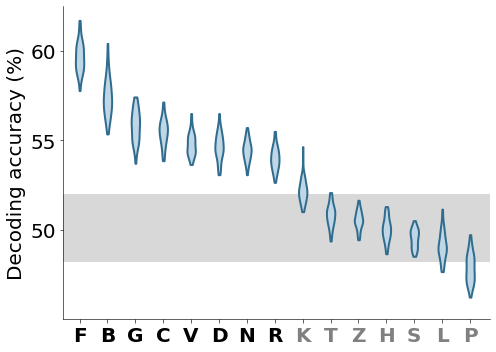

In [9]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patheffects as pe

# ---------- helpers ----------
def benjamini_hochberg(pvals):
    """Return q-values (FDR-adjusted p-values) using the BH procedure."""
    p = np.asarray(pvals, dtype=float)
    m = p.size
    order = np.argsort(p)
    ranked_p = p[order]
    q = np.empty_like(ranked_p)
    prev = 1.0
    for i in range(m - 1, -1, -1):
        q_i = ranked_p[i] * m / (i + 1)
        prev = min(prev, q_i)
        q[i] = prev
    qvals = np.empty_like(q)
    qvals[order] = q
    return qvals

def percentile_pvalue(true_vals, shuffle_vals):
    """
    Two-sided empirical p-value based on the percentile of the TRUE mean
    within the surrogate (SHUFFLE) distribution.

    p = 2 * min( P_shuffle >= true_mean , P_shuffle <= true_mean )
    with +1 smoothing.
    """
    xbar = float(np.median(true_vals))
    s = np.asarray(shuffle_vals, dtype=float)
    n = s.size
    p_ge = (np.sum(s >= xbar) + 1) / (n + 1)
    p_le = (np.sum(s <= xbar) + 1) / (n + 1)
    p_two_sided = 2.0 * min(p_ge, p_le)
    return min(1.0, p_two_sided)

def sig_stars(q):
    if q < 0.001: return '***'
    if q < 0.01:  return '**'
    if q < 0.05:  return '*'
    return ''

# ---------- compute last-step accuracies ----------
# Expects these to already exist in your workspace:
# uniqueLetters
# letter_acc         shape: (n_runs_true,    n_letters, n_steps)
# letter_shuffle_acc shape: (n_runs_shuffle, n_letters, n_steps)

L = min(15, len(uniqueLetters))
T1 = 2
T2 = 16
T = T2 - T1

# True accuracies per letter across runs at the last cumulative step
last_true = np.array([
    np.cumsum(letter_acc[:, i, T1:T2], axis=-1)[:, -1] / T
    for i in range(L)
])  # (L, n_runs_true)

# --------- pooled shuffle across ALL letters ----------
pooled_shuffle = (
    np.cumsum(letter_shuffle_acc[:, :L, T1:T2], axis=-1)[:, :, -1] / T
).reshape(-1)  # (n_runs_shuffle * L,)

# Sort letters by median true accuracy (descending)
order = np.argsort(np.median(last_true, axis=1))[::-1]
ordered_labels = [uniqueLetters[i] for i in order]

# ---------- stats: p-values vs pooled shuffle, BH-FDR correction ----------
pvals = []
for idx in order:
    x_true = last_true[idx]
    pv = percentile_pvalue(x_true, pooled_shuffle)
    pvals.append(pv)
pvals = np.asarray(pvals)
qvals = benjamini_hochberg(pvals)

stats_df = pd.DataFrame({
    "letter": ordered_labels,
    "true_mean":   [np.mean(last_true[i])   for i in order],
    "true_median": [np.median(last_true[i]) for i in order],
    "shuffle_mean":   np.mean(pooled_shuffle),
    "shuffle_median": np.median(pooled_shuffle),
    "shuffle_p05": np.percentile(pooled_shuffle, 5),
    "shuffle_p95": np.percentile(pooled_shuffle, 95),
    "p_value_percentile": pvals,
    "q_value_bh": qvals,
    "signif": [sig_stars(q) for q in qvals],
})
print(stats_df.to_string(index=False))

# ---------- simplified Nature Neuroscience figure (clean) ----------
mpl.rcParams.update({
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.family": "sans-serif",
    "axes.linewidth": 0.6,
    "xtick.direction": "out", "ytick.direction": "out",
    "xtick.major.width": 0.6, "ytick.major.width": 0.6
})

figsize = (7, 5)
FS = 20

COL_TRUE   = "#2F6C8E"
COL_TRUE_L = "#BFD6E6"

# Band settings (neutral gray)
COL_BAND = "#BFBFBF"
COL_BAND_EDGE = "#7A7A7A"

fig, ax = plt.subplots(figsize=figsize)

delta = 0 # 0.18
positions_true = np.arange(L) - delta

data_true = [last_true[i] for i in order]

# --- pooled shuffle band: 5–95 percentile ---
p05 = np.percentile(pooled_shuffle, 5)
p95 = np.percentile(pooled_shuffle, 95)
p50 = np.percentile(pooled_shuffle, 50)

# Make band span across full x-range of the plotted categories
x_left = -0.6
x_right = (L - 1) + 0.7

ax.fill_between([x_left, x_right], [p05, p05], [p95, p95],
                alpha=0.6, linewidth=0, facecolor=COL_BAND, zorder=0)

# Optional: median line of pooled shuffle
#ax.plot([x_left, x_right], [p50, p50], linewidth=1.5, color=COL_BAND_EDGE, zorder=1)

# --- True violins ---
vp_true = ax.violinplot(
    data_true, positions=positions_true,
    widths=0.30, showextrema=False, showmedians=False, showmeans=False
)
for body in vp_true["bodies"]:
    body.set_facecolor(COL_TRUE_L)
    body.set_edgecolor(COL_TRUE)
    body.set_linewidth(2.0)
    body.set_alpha(1)

# --- Significance stars (computed vs pooled shuffle) ---
y_max = np.array([max(np.max(t), p95) for t in data_true])
y_pad = 0.04 * (np.max(y_max) - np.min(y_max))
for xt, q, ymax in zip(positions_true, qvals, y_max):
    stars = sig_stars(q)
    # ax.text(xt, ymax + y_pad, stars, ha="center", va="bottom",
    #         fontsize=FS, color="black")

# Your black lines
#plt.plot([0, 7.5], [0.46, 0.46], color="k", linewidth=4,
#         path_effects=[pe.Stroke(linewidth=2, foreground="k"), pe.Normal()])
#w1 = 0.001
#plt.plot([7.5, 15.5], [0.46 - w1, 0.46 - w1], color="k", linewidth=1)
#w2 = -0.0005
#plt.plot([7.5, 15.5], [0.46 - w2, 0.46 - w2], color="k", linewidth=1)

# Cosmetics
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(x_left, x_right)
ax.set_ylim(0.450, 0.625)
ax.set_ylabel("Decoding accuracy (%)", fontsize=20)
ax.set_xticks(np.arange(L))
ax.set_xticklabels(ordered_labels, rotation=0, ha="center", fontsize=FS)

xticks = ax.get_xticklabels()
for i, label in enumerate(xticks):
    label.set_fontweight("bold")
    label.set_color("black" if i < 8 else "gray")

ax.set_yticks([0.5, 0.55, 0.6], [50, 55, 60], fontsize=FS)
ax.tick_params(labelsize=FS)

plt.subplots_adjust(bottom=0.15, top=0.92, left=0.10, right=0.995)
plt.tight_layout()
plt.show()

fig.savefig("../figure_letters.png", dpi=200)
# fig.savefig("figure_letters.pdf")